# Running the Virtual Ecosystem in Static Mode

## Why use Static Mode?

Imagine standing in a rainforest clearing at dawn. The sun rises, mist lifts, and the
forest slowly comes to life.

Now imagine you could pause parts of this scene — hold
the soil moisture constant, freeze the behaviour of animals, or keep the microclimate
unchanged — while the rest of the ecosystem continues to move through time.

This is the essence of the Static Mode in the Virtual Ecosystem model.

In complex systems where everything interacts it can be hard to isolate what’s
causing what. Static Mode helps untangle this web by letting you "freeze" components
like plants or animals while others remain dynamic. At each model step, static
components reset to their original state (e.g. eaten leaves magically reappear) —
like a controlled reset — so any change comes only from the active, evolving parts.

This setup enables **targeted experiments** within the full model framework. For
example, you can test how vegetation responds to changing temperatures without feedback
from soil moisture changes, or explore animal behaviour in a fixed vegetation landscape.

By choosing which components evolve over time and which stay fixed, Static Mode helps
reveal drivers of ecological change - helping us understand not just
what happens, but why.

```{note}
The Virtual Ecosystem model can, in theory, be run with any combination of one or more
components held static (except `core`). However, not all combinations are equally
meaningful. It's worth
considering your experimental goals carefully and selecting static–dynamic
configurations that best support the processes you want to isolate or understand.
```

## Using the static mode

This example demonstrates how to configure and run the Virtual Ecosystem with selected
components held static (for more technical details,
[see](./configuration/config.md#static-models)). Specifically, we focus on **hydrology**
by keeping the
microclimate, vegetation, animals, litter, and soils fixed. This isolates hydrological
processes and so we can examine how individual model parameters and process
representations influence model behaviour.

We run two experiments:

- HydroDefault: 'hydrology-only' simulation with default configuration
- HydroDry: 'hydrology-only' simulation with reduced initial soil moisture

In practice this means:

- Microclimate is fixed: e.g., temperature and relative humidity stay constant
- Plants are static: e.g. water uptake, transpiration, and interception do not vary
- Soil microbes, litter, and animals do not feedback into hydrology
- Only hydrology processes evolve over time in response to precipitation

Finally, we compare their outputs to the default setup (`ve_example`) where all
components run dynamically.

```{note}
This guide focuses on how to technically configure and run static mode, not on
interpreting the experimental results. This enables you to adapt the setup to suit your
own analysis goals.

The code below to run the Virtual Ecosystem and plot results uses a mixture of the
command line (e.g. `bash` on Linux or MacOS, `powershell` on Windows) and python code.
For the code run at the command line, we currently only show the syntax for using
`bash`. On Windows, you will need to change the paths (for example, to
`C:\Users\username\Temp\...`).
```

### 1: Run `ve_example` as a baseline

Before setting up static experiments, make sure you can run the model successfully.
If you haven’t yet installed and executed the example, follow the
[example instructions](./virtual_ecosystem_in_use) to familiarise yourself with the
setup.

In [1]:
%%bash
# Remove any existing VE data directory in the /tmp/ directory
if [ -d /tmp/ve_example ]; then
  rm -r /tmp/ve_example
fi

Install the example code - do make sure that you don't have an old copy of this example
code in your temporary directory before starting this exercise!

In [2]:
%%bash
# Install the example data directory from the Virtual Ecosystem package
ve_run --install-example /tmp/

Example directory created at:
/tmp/ve_example


Run the example model with the provided full configuration.

In [3]:
%%bash
# Run the example
ve_run /tmp/ve_example/config \
  --outpath /tmp/ve_example/out/ \
  --logfile /tmp/ve_example/out/ve_example.log

Starting Virtual Ecosystem simulation.
Logging to: /tmp/ve_example/out/ve_example.log
* Loading configuration


pyrealm/<unknown>:71: SyntaxWarning: invalid escape sequence '\s'


* Saved compiled configuration: /tmp/ve_example/out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic, animal, litter, plants
* Saved model initial state
* Starting simulation
100%|██████████| 24/24 [00:51<00:00,  2.16s/it]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


### 2: HydroDefault experiment

#### Configure static components

Once the baseline run is complete, you can set up the experiment with default
'hydrology-only' (no changes to parameters or input data):

- **This is essential**: Create a new output folder: `/ve_example/HydroDefault_out/`.
  The Virtual Ecosystem output files have fixed names and cannot be overwritten; if they
  already exist in your output directory, the model will crash.
- Navigate to the `/ve_example/out/` folder.
- Copy the `ve_full_model_configuration.toml` file and rename it, for example to
  `HydroDefault_config.toml`.
- In the new file, set `static = true` for all components
  **except hydrology and core**, e.g.:

  ```toml
  [abiotic]
  static=true
  ```

In [4]:
# Generate the static config file programmatically
import tomllib
from pathlib import Path

import tomli_w

# Create output directory
output_dir = Path("/tmp/ve_example/HydroDefault_out/")
output_dir.mkdir(parents=True, exist_ok=True)

# Check that the directory is empty
if output_dir.exists() and output_dir.is_dir():
    for file in output_dir.iterdir():
        if file.is_file():
            file.unlink()

# Load the original config
with open("/tmp/ve_example/out/ve_full_model_configuration.toml", "rb") as cfg:
    config = tomllib.load(cfg)

# Update the static settings
config["abiotic"]["static"] = True
config["plants"]["static"] = True
config["animal"]["static"] = True
config["soil"]["static"] = True
config["litter"]["static"] = True

# Save to a new file
with open("/tmp/ve_example/static_config/HydroDefault_config.toml", "wb") as out:
    tomli_w.dump(config, out)

#### Run HydroDefault experiment

Now run the model with the new configuration from your command line and make sure that
the `--outpath` command in the second line is followed by the directory of the new
output folder that you just created (here `/tmp/ve_example/HydroDefault_out/`),
and the `--logfile` command in the third line is followed by the same path and a new
file name ending in `.log`:

In [5]:
%%bash
ve_run /tmp/ve_example/static_config/HydroDefault_config.toml \
  --outpath /tmp/ve_example/HydroDefault_out/ \
  --logfile /tmp/ve_example/HydroDefault_out/HydroDefault.log

Starting Virtual Ecosystem simulation.
Logging to: /tmp/ve_example/HydroDefault_out/HydroDefault.log
* Loading configuration


pyrealm/<unknown>:71: SyntaxWarning: invalid escape sequence '\s'


* Saved compiled configuration: /tmp/ve_example/HydroDefault_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic, animal, litter, plants
* Saved model initial state
* Starting simulation
100%|██████████| 24/24 [00:05<00:00,  4.75it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


#### Compare HydroConst results to baseline

To compare the results of the HydroDefault experiment to the fully dynamic `ve_example`,
load the continuous results from `/ve_example/out/` and `/ve_example/HydroDefault_out/`:

In [6]:
import matplotlib.pyplot as plt
import xarray

# Example: load or define your datasets
ve_example = xarray.load_dataset("/tmp/ve_example/out/all_continuous_data.nc")
hydrodefault = xarray.load_dataset(
    "/tmp/ve_example/HydroDefault_out/all_continuous_data.nc"
)

##### Air temperature above the canopy

The air temperature above the canopy is provided by an external data source at each
time step. In the *dynamic abiotic mode*, this input is a time series to the Virtual
Ecosystem that changes over time, allowing the model to respond to seasonal variation in
atmospheric conditions. In *static abiotic mode*, by contrast, the same temperature
value is used repeatedly for every time step throughout the simulation (think of
groundhog day, the movie).

This difference has important implications for the hydrology model behaviour. In dynamic
abiotic mode, fluctuations in air temperature can drive changes in evaporation, soil
moisture, and other hydrological processes, leading to more realistic diurnal and
seasonal cycles. In static abiotic mode, these processes may stabilize at an artificial
equilibrium that reflects the constant atmospheric forcing rather than natural
variability. This makes the static mode useful for isolating the role of internal model
dynamics, but less representative of real-world conditions.

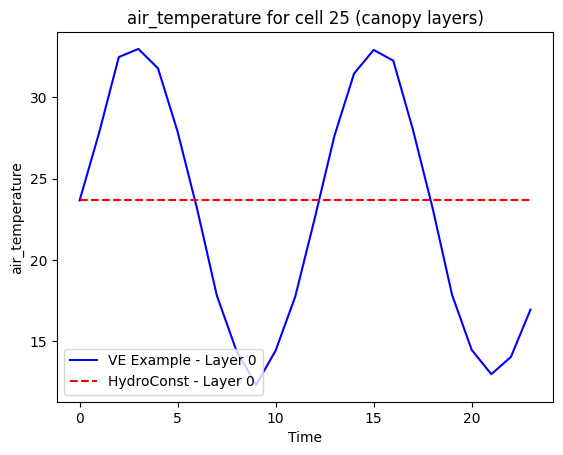

In [7]:
# Choose the variable, cell_id to plot
var_name = "air_temperature"
cell_to_plot = 25

# Select the canopy layers
atmosphere_layers = ve_example.layers[0:1]

# Plot for each of the canopy layers
for layer in atmosphere_layers.values:
    plt.plot(
        ve_example["time_index"],
        ve_example[var_name].sel(cell_id=cell_to_plot, layers=layer),
        label=f"VE Example - Layer {layer}",
        linestyle="-",
        color="blue",
    )
    plt.plot(
        hydrodefault["time_index"],
        hydrodefault[var_name].sel(cell_id=cell_to_plot, layers=layer),
        label=f"HydroConst - Layer {layer}",
        linestyle="--",
        color="red",
    )

plt.xlabel("Time")
plt.ylabel(var_name)
plt.title(f"{var_name} for cell {cell_to_plot} (canopy layers)")
plt.legend()
plt.show()

##### Soil moisture

The next figure shows the evolution of soil moisture over time. Interestingly, the
results appear identical for both the `ve_example` and HydroDefault scenarios. This
suggests that, under the conditions tested, soil moisture dynamics may be relatively
insensitive to fluctuations in abiotic conditions — or that other model components
dominate the response. However, understanding why this occurs would require a deeper
investigation into the model's energy and water balance under both configurations.

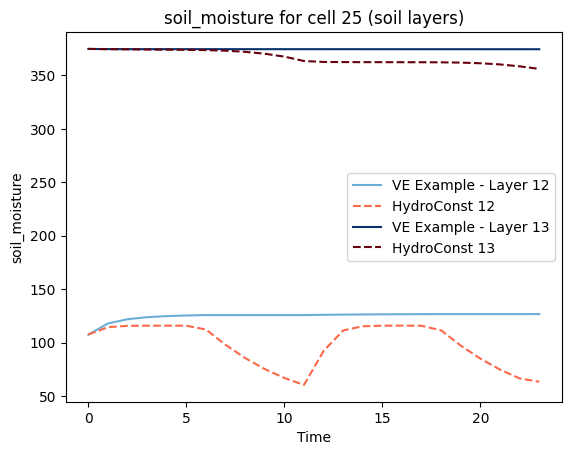

In [13]:
import matplotlib.cm as cm
import numpy as np

# Choose the variable and cell_id to plot
var_name = "soil_moisture"
cell_to_plot = 25

# Select the bottom two layers (soil layers)
soil_layers = ve_example.layers[-2:]
n_layers = len(soil_layers)

# Choose colormaps for each dataset
ve_cmap = cm.Blues(np.linspace(0.5, 1, n_layers))  # Blue shades for ve_example
hydro_cmap = cm.Reds(np.linspace(0.5, 1, n_layers))  # Red shades for hydrodefault

# Plot for each of the bottom two layers
for i, layer in enumerate(soil_layers.values):
    plt.plot(
        ve_example["time_index"],
        ve_example[var_name].sel(cell_id=cell_to_plot, layers=layer),
        label=f"VE Example - Layer {layer}",
        linestyle="-",
        color=ve_cmap[i],
    )
    plt.plot(
        hydrodefault["time_index"],
        hydrodefault[var_name].sel(cell_id=cell_to_plot, layers=layer),
        label=f"HydroConst {layer}",
        linestyle="--",
        color=hydro_cmap[i],
    )

plt.xlabel("Time")
plt.ylabel(var_name)
plt.title(f"{var_name} for cell {cell_to_plot} (soil layers)")
plt.legend()
plt.show()

### 4: HydroDry experiment

#### Configure lower initial soil moisture

To set up a hydrology-only experiment with a change in initial soil moisture, follow
these steps:

- **This is essential:** Create a new output folder for your experiment, for example
  `/ve_example/HydroDry_out/`.
- Navigate to the `/ve_example/out/` folder.
- Copy the `ve_full_model_configuration.toml` file and
  rename to `HydroDry_config.toml`. We moved this file to a separate folder
  `/ve_example/static_config/`.
- Check the status flags are set to `static = true`, for all but the hydrology model.
- Make further changes to your configuration for your experiment. Here, we modify the
  initial soil moisture from the default value of 0.5 to 0.3 (line 2 below):

```toml
  [hydrology]
  initial_soil_moisture = 0.3
  initial_groundwater_saturation = 0.9
  static = false
```

In [9]:
# Create output directory
output_dir = Path("/tmp/ve_example/HydroDry_out/")

# If the directory exists, make sure it is empty otherwise create it
if output_dir.exists() and output_dir.is_dir():
    for file in output_dir.iterdir():
        if file.is_file():
            file.unlink()
else:
    output_dir.mkdir(parents=True, exist_ok=True)

# Load the original config
with open("/tmp/ve_example/static_config/HydroDefault_config.toml", "rb") as cfg:
    config = tomllib.load(cfg)

# Modify initial soil moisture
config["hydrology"]["initial_soil_moisture"] = 0.3

# Save to a new file
with open("/tmp/ve_example/static_config/HydroDry_config.toml", "wb") as out:
    tomli_w.dump(config, out)

#### Run HydroDry experiment

Now run the model with the new configuration from your command line. Again, make sure
that the `--outpath` command in the second line is followed by the directory of the new
output folder that you just created (here `/tmp/ve_example/HydroDry_out/`),
and the `--logfile` command in the third line is followed by the same path and a new
file name ending in `.log`:

In [10]:
%%bash
ve_run /tmp/ve_example/static_config/HydroDry_config.toml \
  --outpath /tmp/ve_example/HydroDry_out/ \
  --logfile /tmp/ve_example/HydroDry_out/HydroDry.log

Starting Virtual Ecosystem simulation.
Logging to: /tmp/ve_example/HydroDry_out/HydroDry.log
* Loading configuration


pyrealm/<unknown>:71: SyntaxWarning: invalid escape sequence '\s'


* Saved compiled configuration: /tmp/ve_example/HydroDry_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic, animal, litter, plants
* Saved model initial state
* Starting simulation
100%|██████████| 24/24 [00:05<00:00,  4.64it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


#### Compare HydroConst and HydroDry results

To compare the results of different initial soil moisture levels in the hydrology-only
configuration, load the continuous results from `/ve_example/HydroDry_out/`:

In [11]:
hydrodry = xarray.load_dataset("/tmp/ve_example/HydroDry_out/all_continuous_data.nc")

##### Soil moisture initial conditions

Now plot the soil moisture over time for both experiments. You will see that while the
lower soil layer reaches a similar level in both runs after a few time steps, the top
soil layer stabilizes at a different level. This suggests that initial conditions may
influence the longer-term behaviour of some variables, even in a simplified setup.

One possible explanation is that the upper soil layer responds more directly to
atmospheric conditions and surface fluxes, and may therefore retain some memory of its
initial state. In contrast, the deeper soil layer could be less sensitive to short-term
changes and more likely to converge across scenarios. However, this behaviour requires
further investigation to understand the underlying dynamics, especially in the context
of a static configuration.

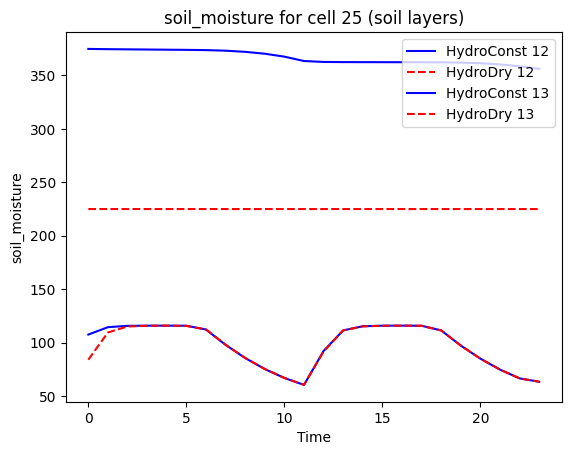

In [ ]:
# Choose the variable and cell_id to plot
var_name = "soil_moisture"
cell_to_plot = 25

# Select the bottom two layers (soil layers)
soil_layers = ve_example.layers[-2:]
n_layers = len(soil_layers)

# Choose colormaps for each dataset
ve_cmap = cm.Blues(np.linspace(0.5, 1, n_layers))  # Blue shades for ve_example
hydro_cmap = cm.Reds(np.linspace(0.5, 1, n_layers))  # Red shades for hydrodefault

# Plot for each of the bottom two layers
for i, layer in enumerate(soil_layers.values):
    plt.plot(
        hydrodefault["time_index"],
        hydrodefault[var_name].sel(cell_id=cell_to_plot, layers=layer),
        label=f"HydroConst {layer}",
        linestyle="-",
        color=ve_cmap[i],
    )
    plt.plot(
        hydrodry["time_index"],
        hydrodry[var_name].sel(cell_id=cell_to_plot, layers=layer),
        label=f"HydroDry {layer}",
        linestyle="--",
        color=hydro_cmap[i],
    )

plt.xlabel("Time")
plt.ylabel(var_name)
plt.title(f"{var_name} for cell {cell_to_plot} (soil layers)")
plt.legend()
plt.show()